In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import pickle

print(os.getcwd())  # Should show the project root 

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap # bone_white, half_black

%load_ext autoreload
%autoreload 2

/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/B_pca_and_pareto_trade-off


In [2]:
# Generate output folder
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis")
output_folder.mkdir(exist_ok=True)

# Load data 
with open(output_folder / "pca_input_df.pkl", "rb") as f:
    pca_input_df_label = pickle.load(f)


pca_input_df = pca_input_df_label.drop(columns="dataset")

# Folder now changed for saving 
output_folder = output_folder / "pca_results"
output_folder.mkdir(exist_ok=True)


In [3]:
# exclude_columns = ["id", "eta", "gamma", "density", "avg_degree", "network_index", "density_bct", "network_idx"]
#                    # "avg_edge_distance", 
#     # 'eta', 'gamma', 'id', 
#     # 'distance_relationship_type', 'preferential_relationship_type', 
#     # 'generative_rule', 'num_iterations', 'network_index',
#     # 'h_params_input_scaling', 'h_params_train_len', 'h_params_n_runs', 
#     # 'h_params_n_lags', 'h_params_test_len', 'h_params_leak_rate', 
#     # 'h_params_bias', 'h_params_n_transient', 'h_params_random_state'


In [4]:
# Get all column names
all_columns = pca_input_df.columns.tolist()

# Filter out excluded columns
feature_columns = [col for col in all_columns] # if col not in exclude_columns]

# Filter out non-numerical columns
feature_columns = [col for col in feature_columns if pd.api.types.is_numeric_dtype(pca_input_df[col])]

# Filter out constant columns
feature_columns = [col for col in feature_columns if pca_input_df[col].nunique() > 1]

# Filter out columns starting with "h_params" (if they exist)
feature_columns = [col for col in feature_columns if not col.startswith("h_params")]


print(f"\nTotal columns: {len(all_columns)}")
# print(f"Excluded columns: {len(exclude_columns)}")
print(f"Feature columns for PCA: {len(feature_columns)}")

# Extract features for PCA
X = pca_input_df[feature_columns].copy()

# Handle missing values
print(f"\nMissing values before handling: {X.isnull().sum().sum()}")
# Print in which columns values are missing 
missing_cols = X.columns[X.isnull().any()].tolist()
print(f"Columns with missing values: {missing_cols}")

# !!!!!!!!!!!!!!!!!
# Exclude these columns from PCA FOR NOW!!!! 
X = X.drop(columns=missing_cols)

# # X = X.fillna(X.mean())  # Fill NaN with column mean
# print(f"Missing values after handling: {X.isnull().sum().sum()}")

# Print how many pos / neg inf values there are in the dataset (if any), and in which columns they are
inf_cols = X.columns[(X == np.inf).any() | (X == -np.inf).any()].tolist()
inf_count_pos = (X == np.inf).sum().sum()
inf_count_neg = (X == -np.inf).sum().sum()
print(f"\nNumber of positive infinite values in the dataset: {inf_count_pos}")
print(f"Number of negative infinite values in the dataset: {inf_count_neg}")
print(f"Columns with infinite values: {inf_cols}")
# !!!!!!!!!!!!!!!!!
# FOR NOW: Exclude these columns from PCA as well, since they contain infinite values.
X = X.drop(columns=inf_cols)


# # Handle infinite values
# X = X.replace([np.inf, -np.inf], np.nan)
# X = X.fillna(X.mean())

# # Drop columns that are all NaN (if any remain)
# X = X.dropna(axis=1, how='all')

# Update feature_columns to match the cleaned data
feature_columns_cleaned = X.columns.tolist()

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Feature columns after cleaning: {len(feature_columns_cleaned)}")
if len(feature_columns_cleaned) != len(feature_columns):
    print(f"Note: {len(feature_columns) - len(feature_columns_cleaned)} columns were removed during cleaning")



Total columns: 125
Feature columns for PCA: 119

Missing values before handling: 10749
Columns with missing values: ['energy', 'eta', 'gamma', 'repertoire_diversity', 'repertoire_size']

Number of positive infinite values in the dataset: 0
Number of negative infinite values in the dataset: 0
Columns with infinite values: []

Final feature matrix shape: (27346, 114)
Feature columns after cleaning: 114
Note: 5 columns were removed during cleaning


In [5]:
# # Get all column names
# all_columns = df_merged.columns.tolist()

# # Filter out excluded columns
# feature_columns = [col for col in all_columns if col not in exclude_columns]

# # Filter out non-numerical columns
# feature_columns = [col for col in feature_columns if pd.api.types.is_numeric_dtype(df_merged[col])]

# # Filter out constant columns
# feature_columns = [col for col in feature_columns if df_merged[col].nunique() > 1]

# # Filter out columns starting with "h_params" (if they exist)
# feature_columns = [col for col in feature_columns if not col.startswith("h_params")]


# print(f"\nTotal columns: {len(all_columns)}")
# print(f"Excluded columns: {len(exclude_columns)}")
# print(f"Feature columns for PCA: {len(feature_columns)}")

# # Extract features for PCA
# X = df_merged[feature_columns].copy()

# # Handle missing values
# print(f"\nMissing values before handling: {X.isnull().sum().sum()}")
# # Print in which columns values are missing 
# missing_cols = X.columns[X.isnull().any()].tolist()
# print(f"Columns with missing values: {missing_cols}")

# # !!!!!!!!!!!!!!!!!
# # Exclude these columns from PCA FOR NOW!!!! 
# X = X.drop(columns=missing_cols)

# # # X = X.fillna(X.mean())  # Fill NaN with column mean
# # print(f"Missing values after handling: {X.isnull().sum().sum()}")

# # Print how many pos / neg inf values there are in the dataset (if any), and in which columns they are
# inf_cols = X.columns[(X == np.inf).any() | (X == -np.inf).any()].tolist()
# inf_count_pos = (X == np.inf).sum().sum()
# inf_count_neg = (X == -np.inf).sum().sum()
# print(f"\nNumber of positive infinite values in the dataset: {inf_count_pos}")
# print(f"Number of negative infinite values in the dataset: {inf_count_neg}")
# print(f"Columns with infinite values: {inf_cols}")
# # !!!!!!!!!!!!!!!!!
# # FOR NOW: Exclude these columns from PCA as well, since they contain infinite values.
# X = X.drop(columns=inf_cols)


# # # Handle infinite values
# # X = X.replace([np.inf, -np.inf], np.nan)
# # X = X.fillna(X.mean())

# # # Drop columns that are all NaN (if any remain)
# # X = X.dropna(axis=1, how='all')

# # Update feature_columns to match the cleaned data
# feature_columns_cleaned = X.columns.tolist()

# print(f"\nFinal feature matrix shape: {X.shape}")
# print(f"Feature columns after cleaning: {len(feature_columns_cleaned)}")
# if len(feature_columns_cleaned) != len(feature_columns):
#     print(f"Note: {len(feature_columns) - len(feature_columns_cleaned)} columns were removed during cleaning")


In [6]:

# Standardize features
print("\nStandardizing features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
print("\nPerforming PCA...")
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNumber of components explaining 95% variance: {n_components_95}")
print(f"Total variance explained by first 10 components: {cumulative_variance[9]:.4f}")

# Create results dataframe
pca_results = pd.DataFrame(
    X_pca[:, :10],  # First 10 principal components
    columns=[f'PC{i+1}' for i in range(10)]
)

# Add back the identifying columns
pca_results['eta'] = pca_input_df['eta'].values
pca_results['gamma'] = pca_input_df['gamma'].values
# pca_results['id'] = pca_input_df['id'].values

# Save PCA results
output_file = output_folder / f"pca_results.csv"
pca_results.to_csv(output_file, index=False)
print(f"\nPCA results saved to: {output_file}")


Standardizing features...

Performing PCA...



Number of components explaining 95% variance: 33
Total variance explained by first 10 components: 0.8059

PCA results saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/pca_results.csv


Explained variance saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/pca_explained_variance.csv

Creating visualizations...
Scree plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/pca_scree_plot.png


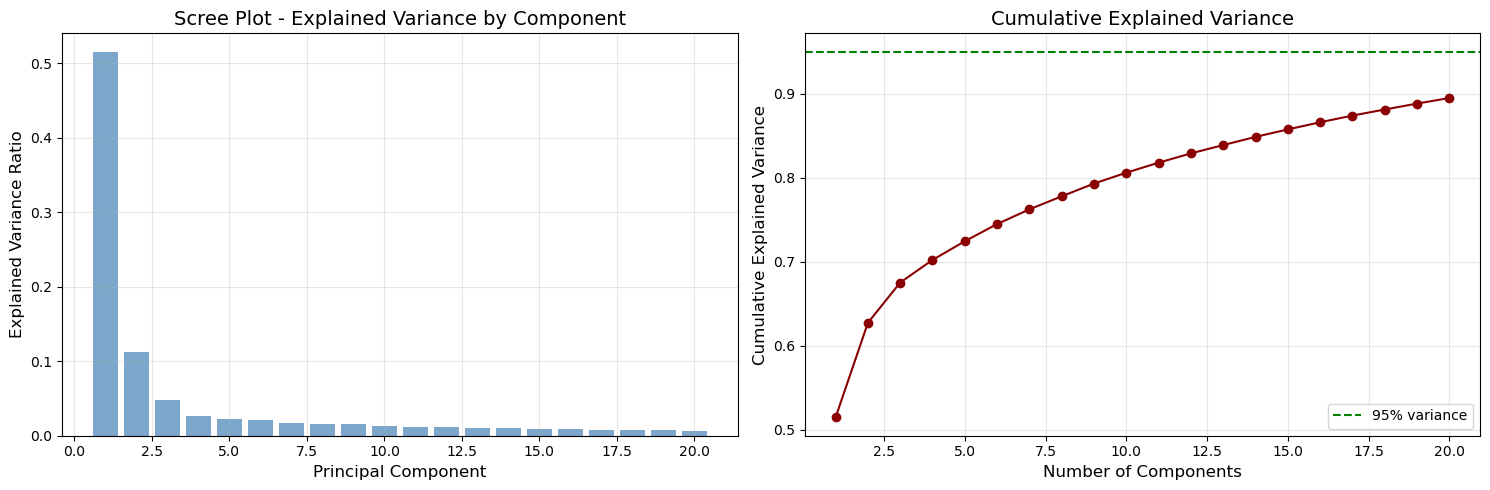

In [7]:

# Save explained variance
variance_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Explained_Variance': explained_variance,
    'Cumulative_Variance': cumulative_variance
})
variance_file = output_folder / f"pca_explained_variance.csv"
variance_df.to_csv(variance_file, index=False)
print(f"Explained variance saved to: {variance_file}")

# Create visualizations
print("\nCreating visualizations...")

# Figure 1: Scree plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot - explained variance
axes[0].bar(range(1, min(21, len(explained_variance)+1)), 
            explained_variance[:20], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Scree Plot - Explained Variance by Component', fontsize=14)
axes[0].grid(alpha=0.3)

# Cumulative variance plot
axes[1].plot(range(1, min(21, len(cumulative_variance)+1)), 
             cumulative_variance[:20], marker='o', color='darkred')
axes[1].axhline(y=0.95, color='green', linestyle='--', label='95% variance')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
scree_file = output_folder / f"pca_scree_plot.png"
plt.savefig(scree_file, dpi=300, bbox_inches='tight')
print(f"Scree plot saved to: {scree_file}")


In [8]:
from config import COLOR_SCHEME

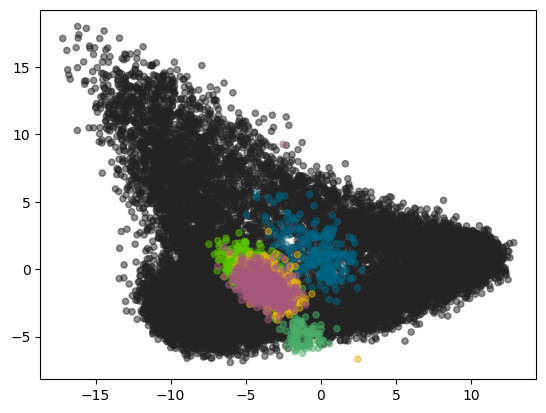

In [9]:
# Color something by pca_input_df['dataset']
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=[COLOR_SCHEME[d] for d in pca_input_df_label['dataset']], 
                     alpha=0.5, s=20)


PC1 vs PC2 scatter plot saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/pca_pc1_pc2_scatter.png


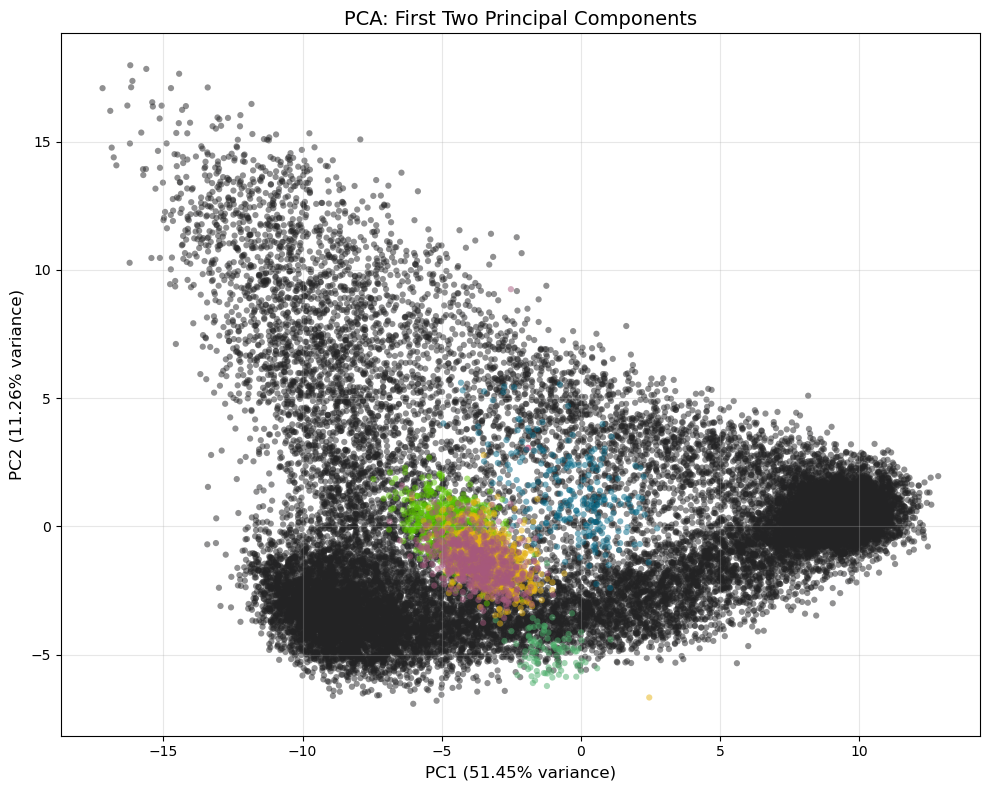

In [10]:
color_values = [COLOR_SCHEME[dataset] for dataset in pca_input_df_label['dataset']]
# Figure 2: PC1 vs PC2 scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=color_values,
                     alpha=0.5, 
                     s=20, 
                     edgecolors="none")
ax.set_xlabel(f'PC1 ({explained_variance[0]:.2%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_variance[1]:.2%} variance)', fontsize=12)
ax.set_title('PCA: First Two Principal Components', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
scatter_file = output_folder / f"pca_pc1_pc2_scatter.png"
plt.savefig(scatter_file, dpi=300, bbox_inches='tight')
print(f"PC1 vs PC2 scatter plot saved to: {scatter_file}")
# plt.close()


Loadings heatmap saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/pca_loadings_heatmap.png


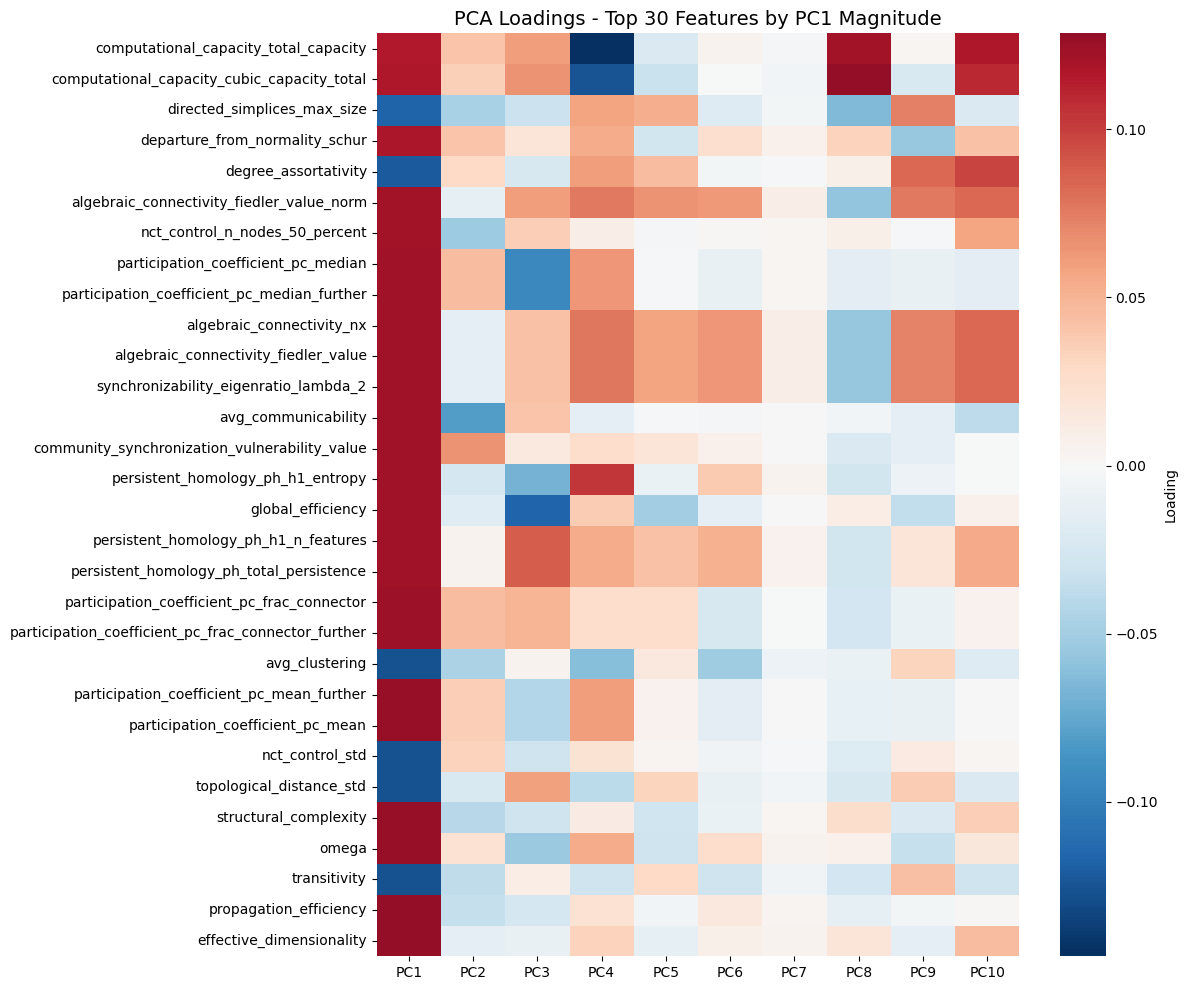

In [11]:
# Figure 3: Loadings heatmap for top components
n_top_components = min(10, pca.components_.shape[0])
n_top_features = min(30, len(feature_columns))  # Top 30 features by loading magnitude

# Get top features by absolute loading on first PC
top_feature_indices = np.argsort(np.abs(pca.components_[0]))[-n_top_features:]
top_feature_names = [feature_columns_cleaned[i] for i in top_feature_indices]

loadings = pca.components_[:n_top_components, top_feature_indices].T

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(loadings, 
            xticklabels=[f'PC{i+1}' for i in range(n_top_components)],
            yticklabels=top_feature_names,
            cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Loading'},
            ax=ax)
ax.set_title(f'PCA Loadings - Top {n_top_features} Features by PC1 Magnitude', fontsize=14)
plt.tight_layout()
loadings_file = output_folder / f"pca_loadings_heatmap.png"
plt.savefig(loadings_file, dpi=300, bbox_inches='tight')
print(f"Loadings heatmap saved to: {loadings_file}")
# plt.close()


In [12]:

# Save full loadings matrix
loadings_full = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])],
    index=feature_columns_cleaned
)
loadings_full_file = output_folder / f"pca_loadings_full.csv"
loadings_full.to_csv(loadings_full_file)
print(f"Full loadings matrix saved to: {loadings_full_file}")

print("\n" + "="*70)
print("PCA Analysis Complete!")
print("="*70)
print(f"\nSummary:")
print(f"  - Total samples: {X.shape[0]}")
print(f"  - Total features: {X.shape[1]}")
print(f"  - Components for 95% variance: {n_components_95}")
print(f"  - Variance explained by PC1: {explained_variance[0]:.2%}")
print(f"  - Variance explained by PC2: {explained_variance[1]:.2%}")
print(f"  - Variance explained by PC1-PC10: {cumulative_variance[9]:.2%}")
print("\nOutput files generated:")
print(f"  1. {output_file}")
print(f"  2. {variance_file}")
print(f"  3. {scree_file}")
print(f"  4. {scatter_file}")
print(f"  5. {loadings_file}")
print(f"  6. {loadings_full_file}")

Full loadings matrix saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/pca_loadings_full.csv

PCA Analysis Complete!

Summary:
  - Total samples: 27346
  - Total features: 114
  - Components for 95% variance: 33
  - Variance explained by PC1: 51.45%
  - Variance explained by PC2: 11.26%
  - Variance explained by PC1-PC10: 80.59%

Output files generated:
  1. /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/pca_results.csv
  2. /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/pca_explained_variance.csv
  3. /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/pca_scree_plot.png
  4. /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results/pca_pc1_pc2_scatter.png
  5. /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_

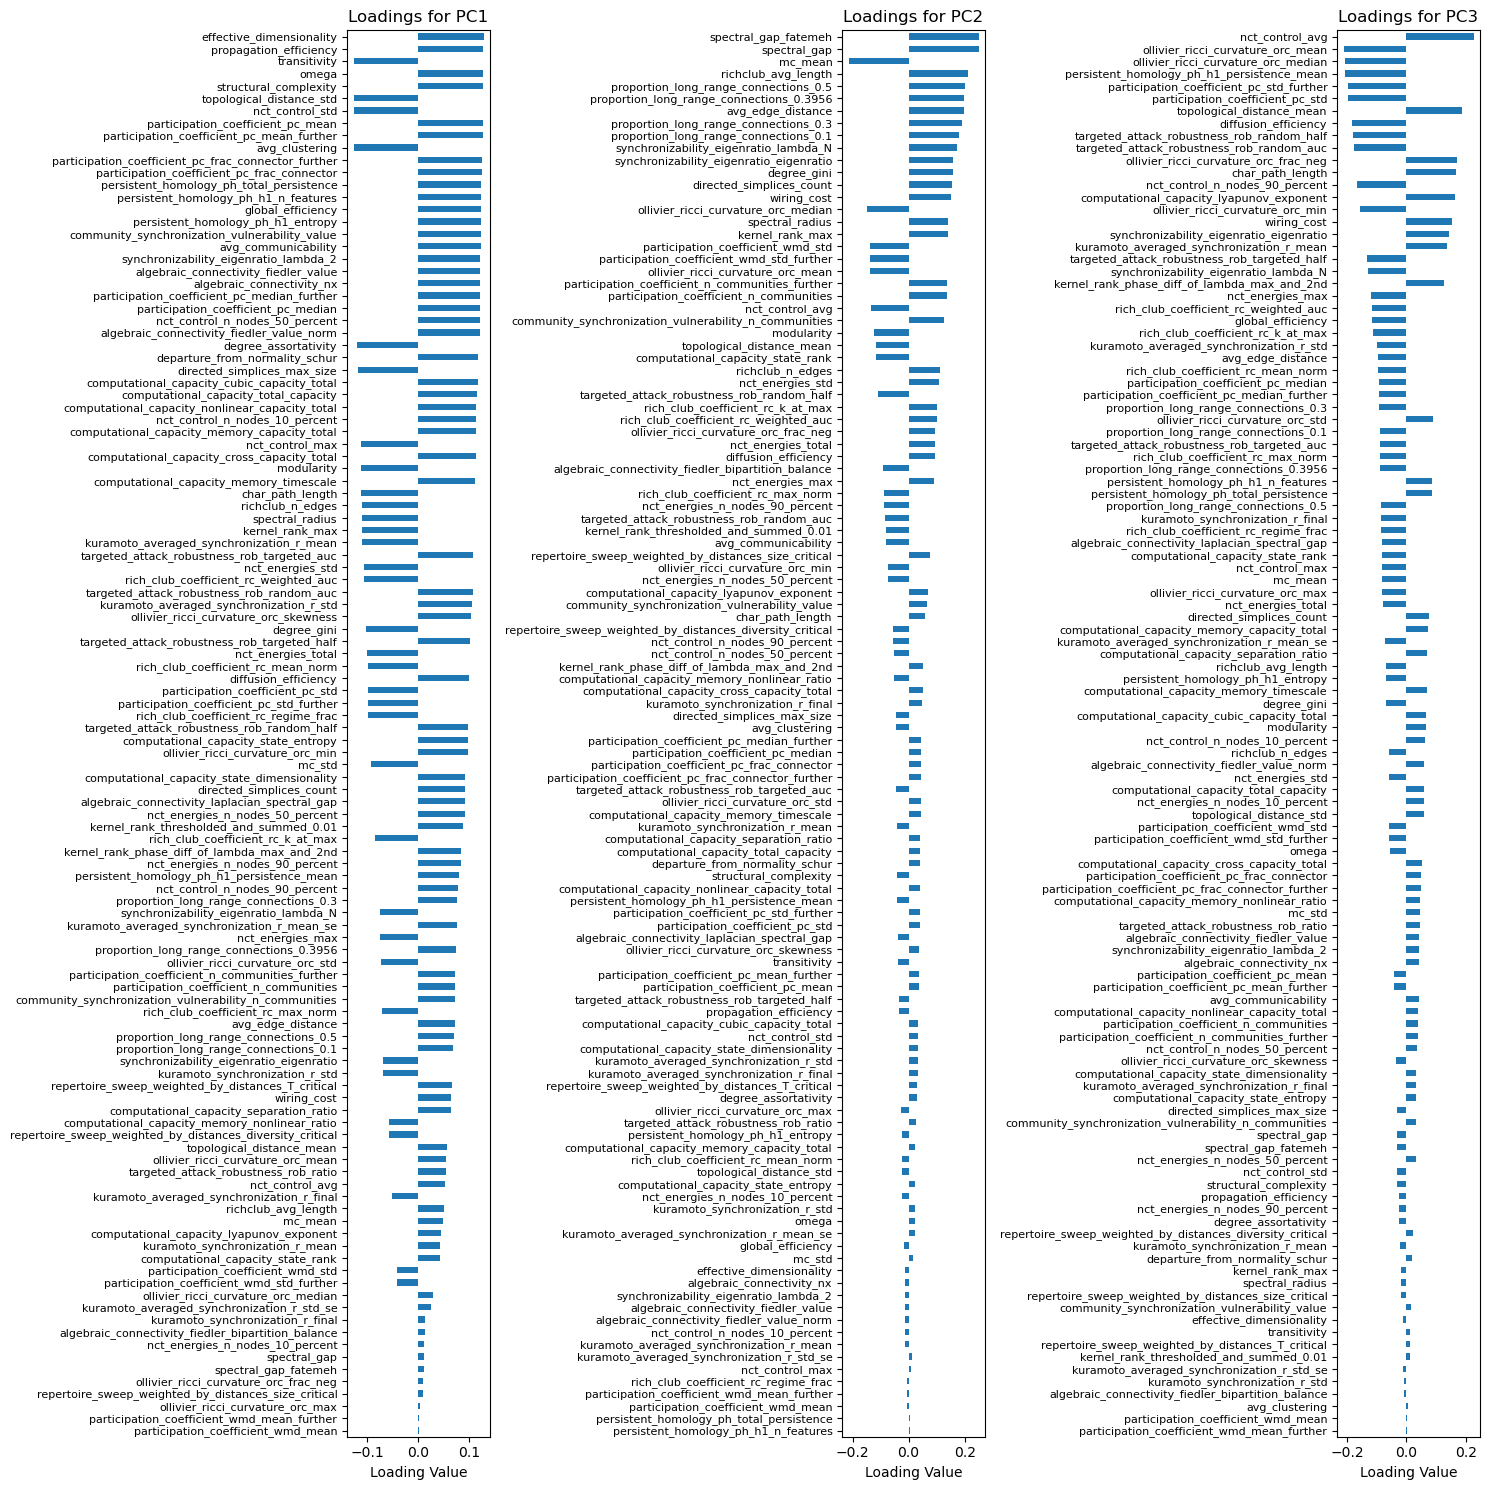

In [13]:
loadings_full

# create loading barplots (3x1) for first 3 PCs
num_pcs_to_plot = 3
fig, axes = plt.subplots(1, num_pcs_to_plot, figsize=(15,15))
for i in range(num_pcs_to_plot):
    pc_loadings = loadings_full[f'PC{i+1}']
    # sort by absolute value
    pc_loadings_sorted = pc_loadings.abs().sort_values(ascending=True)
    # get back old sign for the sorted loadings
    pc_loadings_sorted = pc_loadings_sorted * np.sign(pc_loadings[pc_loadings_sorted.index])
    pc_loadings_sorted.plot(kind='barh', ax=axes[i])
    axes[i].set_title(f'Loadings for PC{i+1}')
    axes[i].set_xlabel('Loading Value')
    # set fontsize of yticklabels to 8
    axes[i].tick_params(axis='y', labelsize=8)
plt.tight_layout()

In [14]:
# ── STEP 1: Find the 3 extreme corner points ──────────────────────────────────

corners = {
    "top_left":    np.argmax(pca_result[:, 1]),                              # max PC2
    "bottom_left": np.argmax(-pca_result[:, 0] - pca_result[:, 1]),         # min PC1 + min PC2
    "right":       np.argmax(pca_result[:, 0]),                              # max PC1
}

print("Corner points:")
for name, idx in corners.items():
    print(f"  {name}: index={idx}, PC1={pca_result[idx,0]:.2f}, PC2={pca_result[idx,1]:.2f}, "
          f"dataset={pca_df_with_dataset_label['dataset'].iloc[idx]}")

# Verify visually
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=pca_df_with_dataset_label['dataset'], alpha=0.5)
for name, idx in corners.items():
    plt.scatter(pca_result[idx, 0], pca_result[idx, 1], s=300, zorder=5, edgecolors='black', linewidths=2)
    plt.annotate(name, (pca_result[idx, 0], pca_result[idx, 1]), textcoords="offset points", xytext=(8, 8), fontsize=10)
plt.title("PCA of Metrics — Selected Corner Points")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

# ── STEP 2: Get the top 6 features by loading magnitude (PC1 + PC2) ───────────

feature_names = pca_df.columns  # from your pipeline: pca_df = pca_df_with_dataset_label.drop(columns="dataset")
loading_magnitude = np.sqrt(pca.components_[0]**2 + pca.components_[1]**2)
top6_idx = np.argsort(loading_magnitude)[::-1][:6]
top6_features = feature_names[top6_idx]

print("\nTop 6 features by PC1+PC2 loading magnitude:")
for feat, mag in zip(top6_features, loading_magnitude[top6_idx]):
    print(f"  {feat}: {mag:.4f}")

# ── STEP 3: Extract standardized values for each corner ───────────────────────

corner_data = {
    name: scaled_data[idx, top6_idx]
    for name, idx in corners.items()
}

# ── STEP 4: Spider plot ────────────────────────────────────────────────────────

labels = [f.replace("_", "\n") for f in top6_features]  # wrap long names
n = len(labels)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]

colors = {"top_left": "steelblue", "bottom_left": "orange", "right": "brown"}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, values in corner_data.items():
    vals = values.tolist() + [values[0]]
    ax.plot(angles, vals, label=name, color=colors[name], linewidth=2)
    ax.fill(angles, vals, alpha=0.15, color=colors[name])

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=9)
ax.set_title("Top 6 Features at PCA Extremes\n(z-scored values)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

NameError: name 'pca_result' is not defined

In [ ]:
from sklearn.manifold import TSNE
import umap

# Run t-SNE and UMAP on the same X_scaled data used for PCA
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

In [ ]:

# Color by PC1 score
color_values = X_pca[:, 0]

fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((12, 6)), dpi=150)

# t-SNE
sc0 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=color_values, cmap=gray_cmap,
                       s=1, alpha=0.5, rasterized=True)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].text(0.05, 0.95, 't-SNE', transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor="black", alpha=0.8))

# UMAP
sc1 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=color_values, cmap=gray_cmap,
                       s=1, alpha=0.5, rasterized=True)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].text(0.05, 0.95, 'UMAP', transform=axes[1].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor="black", alpha=0.8))

plt.tight_layout()
plt.savefig(output_folder / 'tsne_umap_colored_by_pc1.pdf', bbox_inches='tight')
plt.show()

# 1min 17 s

In [ ]:
reducer.graph_

In [ ]:
X

In [ ]:
# Color by PC1 score
color_values = X["wiring_cost"] # _pca[:, 0]

fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((12, 6)), dpi=150)

# t-SNE
sc0 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=color_values, cmap=gray_cmap,
                       s=1, alpha=0.5, rasterized=True)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].text(0.05, 0.95, 't-SNE', transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor="black", alpha=0.8))

# UMAP
sc1 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=color_values, cmap=gray_cmap,
                       s=1, alpha=0.5, rasterized=True)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].text(0.05, 0.95, 'UMAP', transform=axes[1].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor="black", alpha=0.8))

plt.tight_layout()
# plt.savefig(output_folder / 'tsne_umap_colored_by_pc1.pdf', bbox_inches='tight')
plt.show()


In [ ]:
pca_input_df_label['dataset']

In [ ]:
# Color by PC1 score
color_values = [COLOR_SCHEME[d] for d in pca_input_df_label['dataset']]
line_widths = [0 if d == "hcp_schaefer_100_dataset_gnm" else 0.5 for d in pca_input_df_label['dataset']]

fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((12, 6)), dpi=150)

alpha = 0.1
# t-SNE
sc0 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=color_values, cmap=gray_cmap,
                       s=1, alpha=alpha, 
                       linewidth=line_widths,
                       rasterized=True)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].text(0.05, 0.95, 't-SNE', transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor="black", alpha=0.8))

# UMAP
sc1 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=color_values, cmap=gray_cmap, 
                       s=1, alpha=alpha, 
                       linewidth=line_widths,
                       rasterized=True)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].text(0.05, 0.95, 'UMAP', transform=axes[1].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor="black", alpha=0.8))

plt.tight_layout()
# plt.savefig(output_folder / 'tsne_umap_colored_by_pc1.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# =============================================================================
# ICA (Independent Component Analysis)
# =============================================================================
from sklearn.decomposition import FastICA

print("\nPerforming ICA...")
n_components_ica = n_components_95  # Use same n as needed for 95% PCA variance
ica = FastICA(n_components=n_components_ica, random_state=42, max_iter=1000, tol=1e-4)
X_ica = ica.fit_transform(X_scaled)

# Save ICA results
ica_results = pd.DataFrame(
    X_ica[:, :10],
    columns=[f'IC{i+1}' for i in range(min(10, n_components_ica))]
)
ica_results['eta'] = pca_input_df['eta'].values
ica_results['gamma'] = pca_input_df['gamma'].values
ica_results_file = output_folder / "ica_results.csv"
ica_results.to_csv(ica_results_file, index=False)
print(f"ICA results saved to: {ica_results_file}")

# Save ICA mixing matrix (analogous to PCA loadings)
ica_loadings = pd.DataFrame(
    ica.mixing_,  # shape: (n_features, n_components)
    index=feature_columns_cleaned,
    columns=[f'IC{i+1}' for i in range(n_components_ica)]
)
ica_loadings_file = output_folder / "ica_loadings_full.csv"
ica_loadings.to_csv(ica_loadings_file)
print(f"ICA loadings (mixing matrix) saved to: {ica_loadings_file}")

# Plot IC1 vs IC2 colored by dataset
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_ica[:, 0], X_ica[:, 1],
           c=[COLOR_SCHEME[d] for d in pca_input_df_label['dataset']],
           alpha=0.5, s=20)
ax.set_xlabel('IC1', fontsize=12)
ax.set_ylabel('IC2', fontsize=12)
ax.set_title('ICA: First Two Independent Components', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
ica_scatter_file = output_folder / "ica_ic1_ic2_scatter.png"
plt.savefig(ica_scatter_file, dpi=300, bbox_inches='tight')
print(f"ICA scatter plot saved to: {ica_scatter_file}")

# t-SNE and UMAP colored by IC1
fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((12, 6)), dpi=150)
color_values_ic1 = X_ica[:, 0]
for ax, X_embed, label in zip(axes, [X_tsne, X_umap], ['t-SNE', 'UMAP']):
    ax.scatter(X_embed[:, 0], X_embed[:, 1], c=color_values_ic1, cmap=gray_cmap,
               s=1, alpha=0.5, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.05, 0.95, label, transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.8))
plt.tight_layout()
plt.savefig(output_folder / 'tsne_umap_colored_by_ic1.pdf', bbox_inches='tight')
plt.show()

# Loadings barplots for first 3 ICs
num_ics_to_plot = 3
fig, axes = plt.subplots(1, num_ics_to_plot, figsize=(15, 15))
for i in range(num_ics_to_plot):
    ic_loadings = ica_loadings[f'IC{i+1}']
    ic_loadings_sorted = ic_loadings.abs().sort_values(ascending=True)
    ic_loadings_sorted = ic_loadings_sorted * np.sign(ic_loadings[ic_loadings_sorted.index])
    ic_loadings_sorted.plot(kind='barh', ax=axes[i])
    axes[i].set_title(f'Loadings for IC{i+1}')
    axes[i].set_xlabel('Mixing Weight')
    axes[i].tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(output_folder / 'ica_loadings_barplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("ICA complete.")

In [ ]:
# =============================================================================
# Nonlinear PCA (Kernel PCA)
# =============================================================================
from sklearn.decomposition import KernelPCA

print("\nPerforming Kernel PCA (RBF kernel)...")
# RBF is the standard choice; gamma=None defaults to 1/n_features
kpca = KernelPCA(n_components=10, kernel='rbf', gamma=None,
                 fit_inverse_transform=True, random_state=42, n_jobs=-1)
X_kpca = kpca.fit_transform(X_scaled)

# Save Kernel PCA results
kpca_results = pd.DataFrame(
    X_kpca,
    columns=[f'KPC{i+1}' for i in range(10)]
)
kpca_results['eta'] = pca_input_df['eta'].values
kpca_results['gamma'] = pca_input_df['gamma'].values
kpca_results_file = output_folder / "kpca_results.csv"
kpca_results.to_csv(kpca_results_file, index=False)
print(f"Kernel PCA results saved to: {kpca_results_file}")

# Approximate explained variance via variance of each component 
# (KernelPCA doesn't expose explained_variance_ratio_ directly)
kpca_var = np.var(X_kpca, axis=0)
kpca_var_ratio = kpca_var / kpca_var.sum()
kpca_cumvar = np.cumsum(kpca_var_ratio)

kpca_variance_df = pd.DataFrame({
    'KPC': [f'KPC{i+1}' for i in range(10)],
    'Variance': kpca_var,
    'Variance_Ratio': kpca_var_ratio,
    'Cumulative_Variance_Ratio': kpca_cumvar
})
kpca_variance_file = output_folder / "kpca_explained_variance.csv"
kpca_variance_df.to_csv(kpca_variance_file, index=False)
print(f"Kernel PCA variance info saved to: {kpca_variance_file}")
print(kpca_variance_df.to_string(index=False))

# KPC1 vs KPC2 scatter, colored by dataset
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_kpca[:, 0], X_kpca[:, 1],
           c=[COLOR_SCHEME[d] for d in pca_input_df_label['dataset']],
           alpha=0.5, s=20)
ax.set_xlabel(f'KPC1 ({kpca_var_ratio[0]:.2%} variance)', fontsize=12)
ax.set_ylabel(f'KPC2 ({kpca_var_ratio[1]:.2%} variance)', fontsize=12)
ax.set_title('Kernel PCA: First Two Nonlinear Components', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
kpca_scatter_file = output_folder / "kpca_kpc1_kpc2_scatter.png"
plt.savefig(kpca_scatter_file, dpi=300, bbox_inches='tight')
print(f"Kernel PCA scatter plot saved to: {kpca_scatter_file}")

# Scree-style bar plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(range(1, 11), kpca_var_ratio, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Kernel Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Ratio', fontsize=12)
axes[0].set_title('Kernel PCA – Variance per Component', fontsize=14)
axes[0].grid(alpha=0.3)
axes[1].plot(range(1, 11), kpca_cumvar, marker='o', color='darkred')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Variance Ratio', fontsize=12)
axes[1].set_title('Kernel PCA – Cumulative Variance', fontsize=14)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_folder / 'kpca_scree_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

# t-SNE and UMAP colored by KPC1
fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((12, 6)), dpi=150)
color_values_kpc1 = X_kpca[:, 0]
for ax, X_embed, label in zip(axes, [X_tsne, X_umap], ['t-SNE', 'UMAP']):
    ax.scatter(X_embed[:, 0], X_embed[:, 1], c=color_values_kpc1, cmap=gray_cmap,
               s=1, alpha=0.5, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.05, 0.95, label, transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.8))
plt.tight_layout()
plt.savefig(output_folder / 'tsne_umap_colored_by_kpc1.pdf', bbox_inches='tight')
plt.show()

print("Kernel PCA complete.")

# 17 min 30 s

In [ ]:


# Turn eta and gamma into two different colorchannels for the t-SNE and UMAP plots
# For example, use eta for hue and gamma for saturation (or size)
from matplotlib.colors import Normalize

# Normalize the eta and gamma values
eta_norm = Normalize()(pca_input_df_label["eta"])
gamma_norm = Normalize()(pca_input_df_label["gamma"])

# Create a colormap for eta (hue) and gamma (saturation)
# cmap_eta = plt.cm.viridis  # You can choose any colormap you like
# cmap_gamma = plt.cm.gray  # Grayscale for saturation
# # Map normalized eta and gamma to colors
# colors_eta = cmap_eta(eta_norm)
# colors_gamma = cmap_gamma(gamma_norm)
# combined_colors = (colors_eta[:, :3] + colors_gamma[:, :3]) / 2

# cmap_eta = plt.cm.Reds # 
cmap_eta = plt.cm.YlOrRd
cmap_gamma = plt.cm.Blues # Greys # Reds #] Blues
# Map normalized eta and gamma to colors
colors_eta = cmap_eta(eta_norm)
colors_gamma = cmap_gamma(gamma_norm)
# Combine the two color channels (for simplicity, we'll just average them here)
# combined_colors = (colors_eta[:, :3] * colors_gamma[:, :3]) 
# combined_colors = combined_colors / np.max(combined_colors, axis=0)
combined_colors = (colors_eta[:, :3] + colors_gamma[:, :3]) / 2

# Now use combined_colors for the scatter plot

plt.figure(figsize=viz.cm_to_inch((2,2)))
plt.scatter(pca_input_df_label["eta"], 
           pca_input_df_label["gamma"],
        #    X_kpca[:, 0], X_kpca[:, 1],
        #    c=[COLOR_SCHEME[d] for d in pca_input_df_label['dataset']],
           c=combined_colors,
           alpha=0.5, s=2, rasterized=True)
plt.xlabel(r"$\eta$")
plt.ylabel(r"$\gamma$")
# plt.xticks([-8,3])
# plt.yticks([-0.1,1])
plt.xticks([])
plt.yticks([])
plt.xlim(-8,3)
plt.ylim(-0.1,1)

plt.savefig(output_folder / 'tiny_colorgradient.pdf', bbox_inches='tight')
print(output_folder / 'tiny_colorgradient.pdf')

In [ ]:
pca_input_df_label['dataset'].unique()

zorder_dict = {
    "hcp_schaefer_100_dataset_gnm": 1,
    'suarez_MaMI_dataset': 2, 
    "hcp_schaefer_100_dataset": 3, 
    'kaysons_generated_networks_propagation': 4,
    'kaysons_generated_networks_routing': 5,
    'kaysons_generated_networks_diffusion': 6,
}

In [ ]:

# KPC1 vs KPC2 scatter, colored by dataset
fig, ax = plt.subplots(figsize=viz.cm_to_inch((12, 9)))
ax.scatter(X_kpca[:, 0], X_kpca[:, 1],
        #    c=[COLOR_SCHEME[d] for d in pca_input_df_label['dataset']],
           c=combined_colors,
           alpha=0.25, 
           s=2)

# for dataset != "hcp_schaefer_100_dataset_gnm", add a black edge to the points
# get only the indices of the points that are not in the "hcp_schaefer_100_dataset_gnm" dataset
for d in zorder_dict.keys():
        
        if d == "hcp_schaefer_100_dataset_gnm":
            continue
    
        non_gnm_indices = pca_input_df_label[pca_input_df_label['dataset'] == d].index
        ax.scatter(X_kpca[non_gnm_indices, 0], X_kpca[non_gnm_indices, 1],
                c=[COLOR_SCHEME[d] for d in pca_input_df_label.loc[non_gnm_indices, 'dataset']],
                alpha=1, 
                s=15, 
                #    zorder=[zorder_dict[d] for d in pca_input_df_label.loc[non_gnm_indices, 'dataset']],
                edgecolor='black', 
                linewidth=0.5)

ax.set_xlabel(f'KPC1 ({kpca_var_ratio[0]:.2%} variance)', fontsize=12)
ax.set_ylabel(f'KPC2 ({kpca_var_ratio[1]:.2%} variance)', fontsize=12)
ax.set_title('Kernel PCA') # : First Two Nonlinear Components', fontsize=14)
# ax.grid(alpha=0.3)
ax.set_yticks([-0.4, 0, 0.4])
ax.set_xticks([-0.4, 0, 0.4])
plt.tight_layout()
kpca_scatter_file = output_folder / "kpca_kpc1_kpc2_scatter.pdf"
plt.savefig(kpca_scatter_file, dpi=300, bbox_inches='tight')
print(f"Kernel PCA scatter plot saved to: {kpca_scatter_file}")


In [ ]:
# Correlate original features with KPC scores
kpca_corr = pd.DataFrame(X_kpca[:, :5], columns=[f'KPC{i+1}' for i in range(5)])
feature_df = pd.DataFrame(X_scaled, columns=feature_columns_cleaned)

corr_matrix = pd.concat([feature_df, kpca_corr], axis=1).corr().loc[
    feature_columns_cleaned, [f'KPC{i+1}' for i in range(5)]
]

fig, ax = plt.subplots(figsize=(8, max(6, len(feature_columns_cleaned) * 0.25)))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation: Original Features vs Kernel PCA Components')
plt.tight_layout()
plt.savefig(output_folder / 'kpca_feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((16, 7)), dpi=150)

for ax, coords, title in zip(axes,
                              [(X_pca[:, 0], X_pca[:, 1]),
                               (X_kpca[:, 0], X_kpca[:, 1])],
                              ['Linear PCA', 'Kernel PCA (RBF)']):
    ax.scatter(coords[0], coords[1],
               c=[COLOR_SCHEME[d] for d in pca_input_df_label['dataset']],
               alpha=0.4, s=2, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)

plt.suptitle('Linear vs Nonlinear PCA', fontsize=11)
plt.tight_layout()
plt.savefig(output_folder / 'pca_vs_kpca_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((16, 7)), dpi=150)

for ax, coords, title in zip(axes,
                              [(X_pca[:, 0], X_pca[:, 1]),
                               (X_kpca[:, 0], X_kpca[:, 1])],
                              ['Linear PCA', 'Kernel PCA (RBF)']):
    ax.scatter(coords[0], coords[1],
               c=combined_colors, # c=[COLOR_SCHEME[d] for d in pca_input_df_label['dataset']],
               alpha=0.2, s=1, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    
    for d in zorder_dict.keys():
        
        if d == "hcp_schaefer_100_dataset_gnm":
            continue
    
        non_gnm_indices = pca_input_df_label[pca_input_df_label['dataset'] == d].index
        ax.scatter(X_kpca[non_gnm_indices, 0], X_kpca[non_gnm_indices, 1],
                c=[COLOR_SCHEME[d] for d in pca_input_df_label.loc[non_gnm_indices, 'dataset']],
                alpha=1, 
                s=15, 
                #    zorder=[zorder_dict[d] for d in pca_input_df_label.loc[non_gnm_indices, 'dataset']],
                edgecolor='black', 
                linewidth=0.5)

plt.suptitle('Linear vs Nonlinear PCA', fontsize=11)
plt.tight_layout()
plt.savefig(output_folder / 'pca_vs_kpca_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=viz.cm_to_inch((22, 10)), dpi=150)

plot_configs = [
    (X_pca,  'Linear PCA',       'PC1',  'PC2',  'PC3'),
    (X_kpca, 'Kernel PCA (RBF)', 'KPC1', 'KPC2', 'KPC3'),
]

for idx, (X_embed, title, xl, yl, zl) in enumerate(plot_configs):
    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')

    # ── background cloud (GNM / all points) ──────────────────────────────────
    ax.scatter(X_embed[:, 0], X_embed[:, 1], X_embed[:, 2],
               c=combined_colors, alpha=0.15, s=1, rasterized=True, depthshade=True)

    # ── foreground: non-GNM datasets, one at a time for correct zorder ────────
    for d in zorder_dict.keys():
        if d == "hcp_schaefer_100_dataset_gnm":
            continue

        idx_d = pca_input_df_label[pca_input_df_label['dataset'] == d].index
        ax.scatter(X_embed[idx_d, 0], X_embed[idx_d, 1], X_embed[idx_d, 2],
                   c=[COLOR_SCHEME[d]] * len(idx_d),
                   alpha=1, s=15,
                   edgecolor='black', linewidth=0.4,
                   depthshade=False)   # keep colours true at all angles

    ax.set_xlabel(xl, fontsize=7, labelpad=2)
    ax.set_ylabel(yl, fontsize=7, labelpad=2)
    ax.set_zlabel(zl, fontsize=7, labelpad=2)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    ax.set_title(title, fontsize=10)
    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

plt.suptitle('Linear vs Nonlinear PCA — 3D', fontsize=11)
plt.tight_layout()
plt.savefig(output_folder / 'pca_vs_kpca_comparison_3d.png', dpi=300, bbox_inches='tight')
plt.show()